# Constrained Optimization Model Visualizer
Plots $f(x_1, x_2): \mathbb{R}^2 \to \mathbb{R}$ in 3D with color mapping,
and the feasible set $X = \{(x_1,x_2) \mid g_i(x)=0,\; h_j(x)\leq 0\}$ as a shaded 2D region.

In [1]:
# ── Install dependencies if needed ──────────────────────────────────────────
# %pip install numpy matplotlib sympy ipywidgets --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401
from matplotlib import cm
import sympy as sp
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ✓')

Libraries loaded ✓


## ① Define your problem here

In [3]:
# ── Objective function ───────────────────────────────────────────────────────
# Write f as a Python expression using x1 and x2.
f_expr_str = "x1**2 + x2**2"         # <── CHANGE THIS

# ── Equality constraints  g(x) = 0 ──────────────────────────────────────────
# List of strings; leave empty [] for none.
equality_constraints = [
    # "x1 + x2 - 1"      # means x1 + x2 - 1 = 0  →  x1 + x2 = 1
]                         # <── CHANGE THIS

# ── Inequality constraints  h(x) ≤ 0 ────────────────────────────────────────
# List of strings; leave empty [] for none.
inequality_constraints = [
    "x1**2 + x2**2 - 4",   # means x1²+x2²-4 ≤ 0  →  x1²+x2² ≤ 4
    "-x1",                  # means -x1 ≤ 0        →  x1 ≥ 0
    "-x2",                  # means -x2 ≤ 0        →  x2 ≥ 0
]                           # <── CHANGE THIS

# ── Plot domain ──────────────────────────────────────────────────────────────
x1_range = (-3, 3)          # (min, max)
x2_range = (-3, 3)
n_grid   = 300              # resolution (increase for smoother, decrease for speed)

## ② Parse & evaluate

In [4]:
# ── Parse expressions with sympy then lambdify for fast numpy evaluation ─────
x1_sym, x2_sym = sp.symbols('x1 x2', real=True)

def parse_expr(expr_str):
    """Parse a string expression and return a numpy-callable function."""
    sym_expr = sp.sympify(expr_str, locals={'x1': x1_sym, 'x2': x2_sym})
    return sp.lambdify((x1_sym, x2_sym), sym_expr, modules='numpy'), sym_expr

f_func, f_sym = parse_expr(f_expr_str)
print(f'f(x1,x2) = {f_sym}')

eq_funcs, eq_syms = [], []
for s in equality_constraints:
    fn, sym = parse_expr(s)
    eq_funcs.append(fn); eq_syms.append(sym)
    print(f'  Equality : {sym} = 0')

ineq_funcs, ineq_syms = [], []
for s in inequality_constraints:
    fn, sym = parse_expr(s)
    ineq_funcs.append(fn); ineq_syms.append(sym)
    print(f'  Inequality: {sym} ≤ 0')

f(x1,x2) = x1**2 + x2**2
  Inequality: x1**2 + x2**2 - 4 ≤ 0
  Inequality: -x1 ≤ 0
  Inequality: -x2 ≤ 0


In [5]:
# ── Build grid ───────────────────────────────────────────────────────────────
X1 = np.linspace(*x1_range, n_grid)
X2 = np.linspace(*x2_range, n_grid)
X1g, X2g = np.meshgrid(X1, X2)

# Objective values
Fg = f_func(X1g, X2g).astype(float)

# Feasibility mask
eps_eq = 0.08  # tolerance band for equality constraints on a discrete grid
feasible = np.ones_like(X1g, dtype=bool)

for fn in eq_funcs:
    val = fn(X1g, X2g).astype(float)
    feasible &= (np.abs(val) <= eps_eq)

for fn in ineq_funcs:
    val = fn(X1g, X2g).astype(float)
    feasible &= (val <= 0)

print(f'Grid shape : {X1g.shape}')
print(f'Feasible pts: {feasible.sum()} / {feasible.size}')

Grid shape : (300, 300)
Feasible pts: 7806 / 90000


## ③ Plot

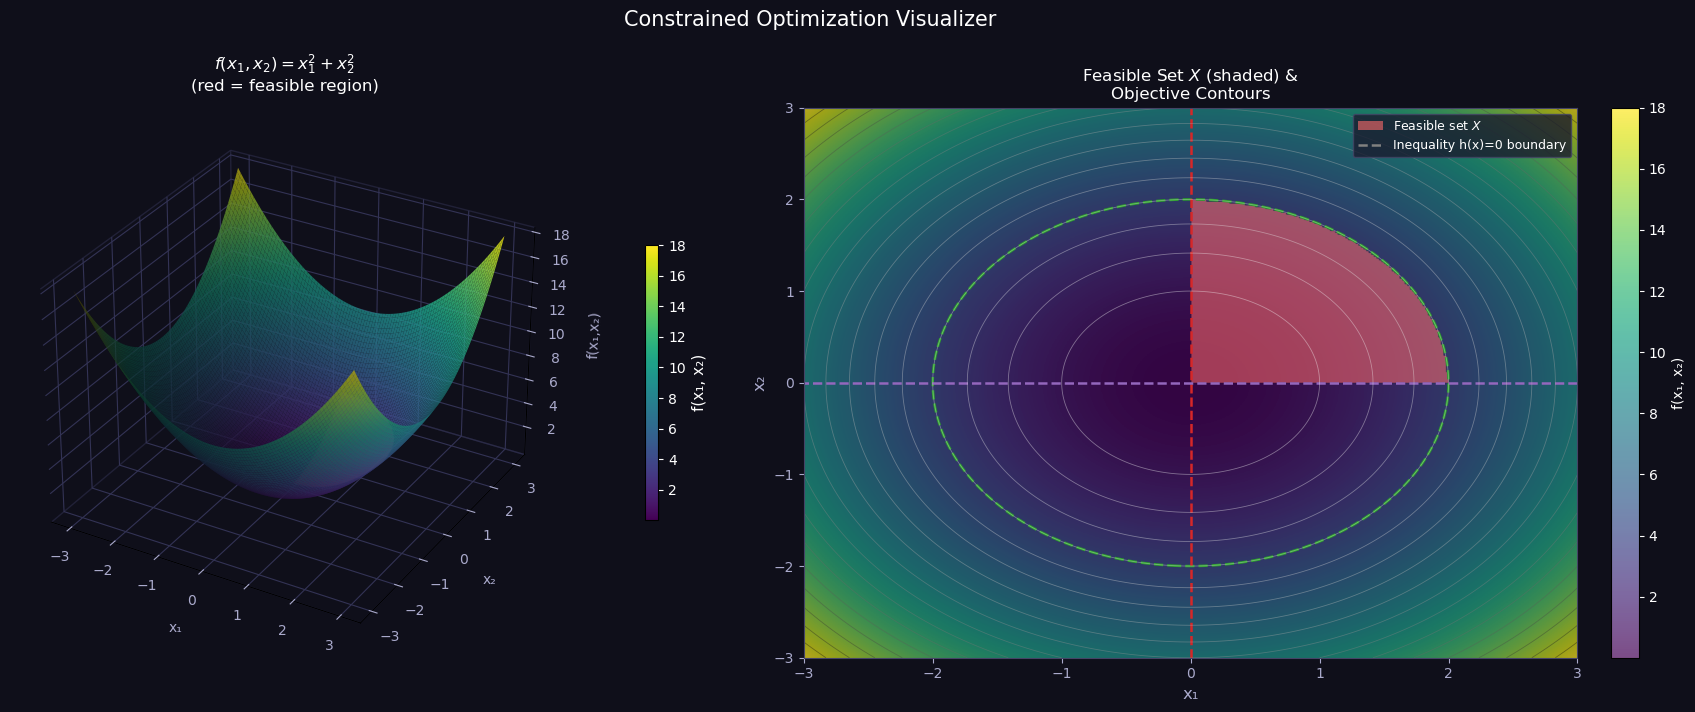

Plot saved as constrained_viz.png


In [6]:
# ── Colour-map setup ──────────────────────────────────────────────────────────
cmap_surface = cm.viridis
cmap_feasible = cm.YlOrRd

# Normalise f for coloring
f_min, f_max = np.nanmin(Fg), np.nanmax(Fg)
norm = mcolors.Normalize(vmin=f_min, vmax=f_max)

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 7))
fig.patch.set_facecolor('#0f0f1a')

# ─── Left panel: 3-D surface ──────────────────────────────────────────────────
ax3d = fig.add_subplot(121, projection='3d')
ax3d.set_facecolor('#0f0f1a')

surf = ax3d.plot_surface(
    X1g, X2g, Fg,
    facecolors=cmap_surface(norm(Fg)),
    rstride=3, cstride=3,
    linewidth=0, antialiased=True, alpha=0.85
)

# Overlay feasible region on the 3-D surface (project onto surface itself)
Fg_feas = np.where(feasible, Fg, np.nan)
ax3d.plot_surface(
    X1g, X2g, Fg_feas,
    color='#ff6b6b', alpha=0.6,
    rstride=3, cstride=3, linewidth=0
)

# Colourbar for f
sm = cm.ScalarMappable(cmap=cmap_surface, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax3d, shrink=0.5, pad=0.1)
cbar.set_label('f(x₁, x₂)', color='white', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# Axis styling
for axis in [ax3d.xaxis, ax3d.yaxis, ax3d.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('#333355')
    axis._axinfo['grid']['color'] = '#333355'

ax3d.tick_params(colors='#aaaacc')
ax3d.set_xlabel('x₁', color='#aaaacc', labelpad=8)
ax3d.set_ylabel('x₂', color='#aaaacc', labelpad=8)
ax3d.set_zlabel('f(x₁,x₂)', color='#aaaacc', labelpad=8)
ax3d.set_title(f'$f(x_1,x_2) = {sp.latex(f_sym)}$\n(red = feasible region)',
               color='white', fontsize=12, pad=12)
ax3d.view_init(elev=30, azim=-60)

# ─── Right panel: 2-D feasible set ────────────────────────────────────────────
ax2d = fig.add_subplot(122)
ax2d.set_facecolor('#0f0f1a')

# Background: f colour map
img = ax2d.imshow(
    Fg,
    extent=[x1_range[0], x1_range[1], x2_range[0], x2_range[1]],
    origin='lower', cmap=cmap_surface, norm=norm, aspect='auto', alpha=0.7
)

# Feasible region shading
feas_rgba = np.zeros((*feasible.shape, 4))
feas_rgba[feasible] = [1.0, 0.42, 0.42, 0.55]   # semi-transparent coral
ax2d.imshow(
    feas_rgba,
    extent=[x1_range[0], x1_range[1], x2_range[0], x2_range[1]],
    origin='lower', aspect='auto'
)

# Draw equality constraint curves
for fn, sym in zip(eq_funcs, eq_syms):
    val = fn(X1g, X2g).astype(float)
    ax2d.contour(X1g, X2g, val, levels=[0],
                 colors=['#00ffcc'], linewidths=2.5, linestyles='solid')

# Draw inequality constraint boundary curves
for i, (fn, sym) in enumerate(zip(ineq_funcs, ineq_syms)):
    val = fn(X1g, X2g).astype(float)
    cs = ax2d.contour(X1g, X2g, val, levels=[0],
                      colors=[f'C{i+2}'], linewidths=1.8, linestyles='dashed')

# Contour lines of f
ax2d.contour(X1g, X2g, Fg, levels=20, cmap='Greys', alpha=0.4, linewidths=0.6)

# Legend patches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elems = [
    Patch(facecolor='#ff6b6b', alpha=0.6, label='Feasible set $X$'),
]
if equality_constraints:
    legend_elems.append(Line2D([0],[0], color='#00ffcc', lw=2.5, label='Equality g(x)=0'))
if inequality_constraints:
    legend_elems.append(Line2D([0],[0], color='grey', lw=1.8, ls='--', label='Inequality h(x)=0 boundary'))
ax2d.legend(handles=legend_elems, loc='upper right',
            facecolor='#1a1a2e', edgecolor='#444466', labelcolor='white', fontsize=9)

# Colourbar
cbar2 = fig.colorbar(img, ax=ax2d, fraction=0.046, pad=0.04)
cbar2.set_label('f(x₁, x₂)', color='white', fontsize=10)
cbar2.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white')

ax2d.tick_params(colors='#aaaacc')
ax2d.set_xlabel('x₁', color='#aaaacc', fontsize=12)
ax2d.set_ylabel('x₂', color='#aaaacc', fontsize=12)
ax2d.set_title('Feasible Set $X$ (shaded) &\nObjective Contours',
               color='white', fontsize=12)
for spine in ax2d.spines.values():
    spine.set_edgecolor('#444466')

plt.suptitle('Constrained Optimization Visualizer', color='white', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('constrained_viz.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Plot saved as constrained_viz.png')